# Small notebooks that demonstrate metrics calculations


This assumes that both GT and predictions are available in csv format:
```
row_id,tomo_id,Motor axis 0,Motor axis 1,Motor axis 2,Array shape (axis 0),Array shape (axis 1),Array shape (axis 2),Voxel spacing,Number of motors
1,tomo_00e047,169.0,546.0,603.0,300,959,928,15.6,1
8,tomo_01a877,147.0,638.0,286.0,300,960,928,13.1,1
...

```

In [8]:
import pandas as pd
import numpy as np
import os
import sys

# Add project root to system path (for relative imports to work)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
print(f"Project root: {project_root}")

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.utils.matching import points_matching_dataset

COLS = ["Motor axis 0", "Motor axis 1", "Motor axis 2"]

Project root: /home/h4/kein254g/BYU_Locating_Bacterial_Flagellar_Motors_2025


In [18]:
df_gt = pd.read_csv("train_labels.csv")
df_gt.sort_values(by="tomo_id", inplace=True)

df_gt.head()

,row_id,tomo_id,Motor axis 0,Motor axis 1,Motor axis 2,Array shape (axis 0),Array shape (axis 1),Array shape (axis 2),Voxel spacing,Number of motors
309,0,tomo_003acc,-1.0,-1.0,-1.0,500,1912,1847,6.5,0
0,1,tomo_00e047,169.0,546.0,603.0,300,959,928,15.6,1
1,8,tomo_01a877,147.0,638.0,286.0,300,960,928,13.1,1
310,10,tomo_0308c5,-1.0,-1.0,-1.0,300,960,928,15.6,0
311,11,tomo_0333fa,-1.0,-1.0,-1.0,300,960,928,16.8,0


## Create a fake prediction by removing some rows and adding some random noise


In [20]:
df_pred = df_gt.copy()
drop_frac = 0.2
df_pred = df_pred.iloc[
    np.random.choice(df_pred.shape[0], size=int(df_pred.shape[0] * (1 - drop_frac)), replace=False)
]
df_pred[COLS] = df_pred[COLS] + np.random.randint(-40, 40, df_pred[COLS].shape)
df_pred.sort_values(by="tomo_id", inplace=True)

df_pred.head()

,row_id,tomo_id,Motor axis 0,Motor axis 1,Motor axis 2,Array shape (axis 0),Array shape (axis 1),Array shape (axis 2),Voxel spacing,Number of motors
0,1,tomo_00e047,160.0,525.0,624.0,300,959,928,15.6,1
310,10,tomo_0308c5,24.0,7.0,19.0,300,960,928,15.6,0
311,11,tomo_0333fa,2.0,-4.0,-32.0,300,960,928,16.8,0
2,14,tomo_0363f2,62.0,582.0,397.0,300,960,928,13.1,1
312,16,tomo_049310,1.0,-31.0,25.0,500,924,956,19.7,0



## Convert Dataframe to points list per tomogram



In [21]:
def create_points_list(df_gt, df_pred, COLS=["Motor axis 0", "Motor axis 1", "Motor axis 2"]):
    all_tomos = sorted(pd.concat([df_gt, df_pred])["tomo_id"].unique())
    p_gt = [df_gt[df_gt["tomo_id"] == tomo][COLS].to_numpy() for tomo in all_tomos]
    p_pred = [df_pred[df_pred["tomo_id"] == tomo][COLS].to_numpy() for tomo in all_tomos]
    return p_gt, p_pred


# Create p_gt: list of numpy arrays, one for each tomo_id using groupby
p_gt, p_pred = create_points_list(df_gt, df_pred)

print(f"Found {len(p_gt)} GT tomogram predictions")
print(f"Found {len(p_pred)} Pred tomogram predictions")

Found 451 GT tomogram predictions
Found 451 Pred tomogram predictions


## Compute stats for single cutoff distance 


    

In [22]:
cutoff_distance = 50
stats = points_matching_dataset(p_gt, p_pred, cutoff_distance=cutoff_distance)

print(f"Stats for cutoff distance = {cutoff_distance}:\n")
for key, value in vars(stats).items():
    print(f"{key:20s} {value:.4f}")

Stats for cutoff distance = 50:

tp                   0.7849
fp                   0.1153
fn                   0.3415
accuracy             0.6928
precision            0.8996
recall               0.6954
f1                   0.6986
mean_dist            24.8483
panoptic_quality     0.2106


## Compute stats for a range of cutoff distances



In [28]:
cutoff_distances = np.linspace(1, 100, 10)

all_stats = tuple(
    points_matching_dataset(p_gt, p_pred, cutoff_distance=cutoff_distance)
    for cutoff_distance in cutoff_distances
)

all_f1 = np.array([stat.f1 for stat in all_stats])
all_precision = np.array([stat.precision for stat in all_stats])
all_recall = np.array([stat.recall for stat in all_stats])

print(cutoff_distances)
print(all_f1.round(4))

[  1.  12.  23.  34.  45.  56.  67.  78.  89. 100.]
[0.     0.0067 0.0894 0.2743 0.5964 0.7718 0.7958 0.7981 0.7981 0.7981]


## Plot metrics

In [32]:
# Create DataFrame with metrics, this makes it easier for further plotting
df_metrics = pd.DataFrame(
    {
        "cutoff_distance": cutoff_distances,
        "f1": all_f1,
        "precision": all_precision,
        "recall": all_recall,
    }
)

# Melt to get metric names in single column
df_metrics = df_metrics.melt(
    id_vars=["cutoff_distance"],
    value_vars=["f1", "precision", "recall"],
    var_name="metric",
    value_name="value",
)

In [33]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt

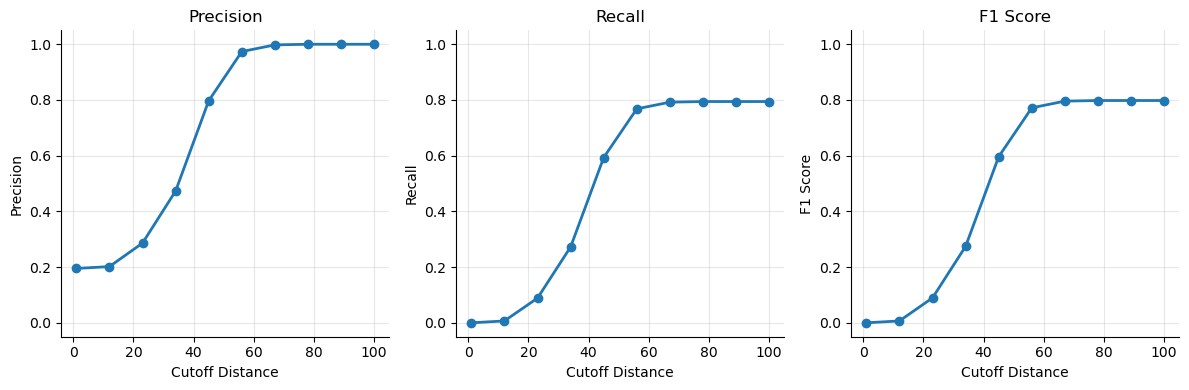

In [ ]:
# Create 3 subplots for precision, recall, and f1
fig, axes = plt.subplots(1, 3, figsize=(12, 4), num=1, clear=True)

# Plot each metric using a loop with zip
metrics = [all_precision, all_recall, all_f1]
titles = ["Precision", "Recall", "F1 Score"]
colors = ["tab:blue", "tab:orange", "tab:green"]

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    ax.plot(cutoff_distances, metric, "o-", color=color, linewidth=2, markersize=6)
    ax.set_title(title)
    ax.set_xlabel("Cutoff Distance")
    ax.set_ylabel(title)
    ax.set_ylim(-0.05, 1.05)
    sns.despine()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()